In [32]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [185]:
df = pd.read_csv("Mall_Customers.csv")

In [194]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [189]:
df.nunique()

,0
CustomerID,200
Genre,2
Age,51
Annual Income (k$),64
Spending Score (1-100),84


In [190]:
X = df.iloc[:, 2:5].values
y = df.iloc[:, 1].values

In [191]:
y

array(['Male', 'Male', 'Female', 'Female', 'Female', 'Female', 'Female',
       'Female', 'Male', 'Female', 'Male', 'Female', 'Female', 'Female',
       'Male', 'Male', 'Female', 'Male', 'Male', 'Female', 'Male', 'Male',
       'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female',
       'Female', 'Male', 'Female', 'Male', 'Male', 'Female', 'Female',
       'Female', 'Female', 'Female', 'Female', 'Female', 'Male', 'Male',
       'Female', 'Female', 'Female', 'Female', 'Female', 'Female',
       'Female', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male',
       'Female', 'Male', 'Female', 'Male', 'Male', 'Male', 'Female',
       'Female', 'Male', 'Male', 'Female', 'Female', 'Male', 'Female',
       'Male', 'Female', 'Female', 'Female', 'Male', 'Male', 'Female',
       'Male', 'Female', 'Female', 'Male', 'Male', 'Male', 'Female',
       'Female', 'Male', 'Female', 'Female', 'Female', 'Female', 'Female',
       'Male', 'Male', 'Female', 'Female', 'Male', 'Female', 'Female',


In [195]:
#import labelencoder
from sklearn.preprocessing import LabelEncoder

In [196]:
y = LabelEncoder().fit_transform(y)

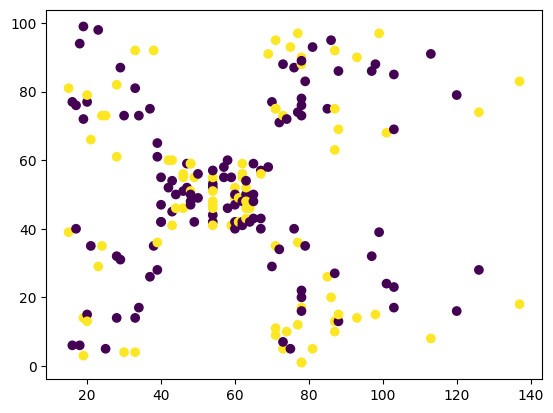

In [197]:
plt.scatter(X[:, 1], X[:, 2], c = y)

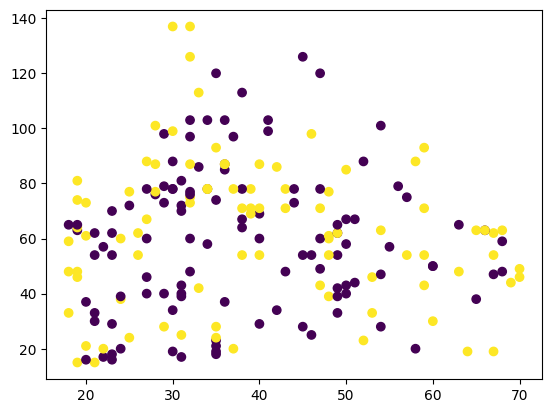

In [227]:
plt.scatter(X[:, 0], X[:, 1], c = y)

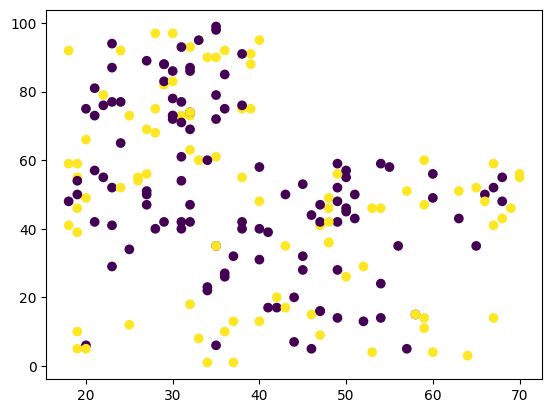

In [228]:
plt.scatter(X[:, 0], X[:, 2], c = y)

In [198]:
from sklearn.model_selection import train_test_split

In [199]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [200]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [201]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [202]:
from sklearn.cluster import KMeans

In [229]:
## Elbow method to select K value, k-means++
wcss = []

for k in range(1, 10):
  kmeans = KMeans(n_clusters = k, init = 'k-means++')
  kmeans.fit(X_train_scaled)
  wcss.append(kmeans.inertia_)

In [230]:
wcss

[402.0000000000001,
 266.4307784285514,
 200.69223897197656,
 135.73224219950123,
 118.54877172045964,
 89.60580134949907,
 82.44108809830445,
 71.19436980129186,
 67.08133519704147]

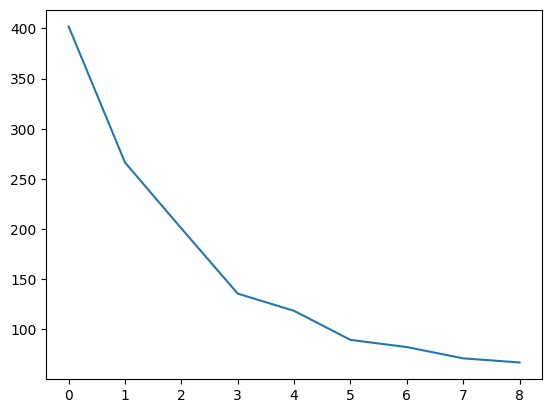

In [231]:
plt.plot(wcss)

In [206]:
# Elbow is at 5 clusters
kmeans = KMeans(n_clusters = 2, init = 'k-means++')
kmeans.fit(X_train_scaled)

KMeans(n_clusters=2)

In [207]:
# Accuracy
kmeans.score(X_train_scaled), kmeans.score(X_test_scaled)

(-266.4307784285513, -102.65535299212245)

In [208]:
y_pred = kmeans.predict(X_test_scaled)
y_pred

array([0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1],
      dtype=int32)

In [209]:
y_test

array([1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0])

In [210]:
!pip install kneed

In [211]:
from kneed import KneeLocator

In [234]:
kl = KneeLocator(range(1, 10), wcss, curve='convex', direction='decreasing')

In [235]:
kl.elbow

np.int64(4)

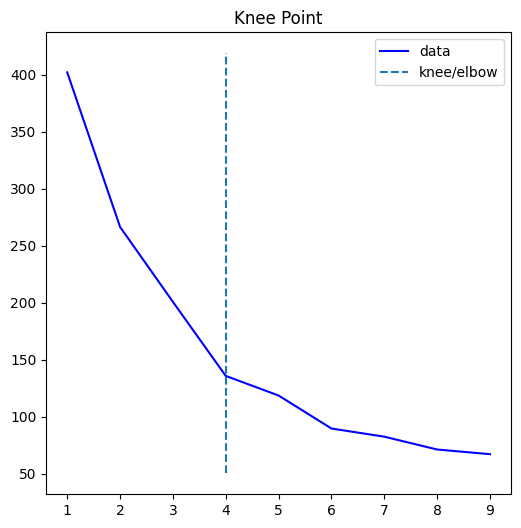

In [236]:
#plot the kl
kl.plot_knee()

In [217]:
## Silhoutte score
from sklearn.metrics import silhouette_score

In [224]:
silhouette_coefficients = []
for k in range(2, 12):
  kmeans3 = KMeans(n_clusters = k, init = 'k-means++')
  kmeans3.fit(X_train_scaled)
  score = silhouette_score(X_train_scaled, kmeans3.labels_)
  silhouette_coefficients.append(score)

In [225]:
silhouette_coefficients

[np.float64(0.32704530198184956),
 np.float64(0.3209362191580193),
 np.float64(0.4106192239138324),
 np.float64(0.38862083528668023),
 np.float64(0.431098360593721),
 np.float64(0.39928474018752746),
 np.float64(0.3597094358719056),
 np.float64(0.4005482293999543),
 np.float64(0.3605304340405143),
 np.float64(0.3968344976936325)]

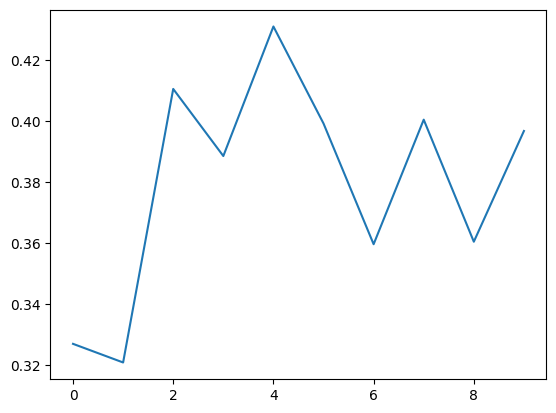

In [226]:
plt.plot(silhouette_coefficients)

## Trying K Median

In [84]:
def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))

def kmedians(X, k, max_iters=100, tol=1e-4, random_state=None):
    np.random.seed(random_state)

    # Step 1: Initialize cluster centers randomly
    indices = np.random.choice(len(X), k, replace=False)
    centers = X[indices]

    for _ in range(max_iters):
        distances = np.zeros((len(X), k))

        # Step 2: Compute distances from each point to each center
        for i, x in enumerate(X):
            for j, c in enumerate(centers):
                distances[i, j] = manhattan_distance(x, c)

        # Step 3: Assign each point to nearest cluster
        labels = np.argmin(distances, axis=1)

        new_centers = np.copy(centers)

        # Step 4: Recompute cluster centers as median of assigned points
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                new_centers[i] = np.median(cluster_points, axis=0)

        # Step 5: Check convergence
        if np.all(np.abs(new_centers - centers) < tol):
            break

        centers = new_centers

    # Optional: compute total within-cluster distance
    total_distance = np.sum([distances[i, labels[i]] for i in range(len(X))])

    return centers, labels, distances, total_distance

In [89]:
## Elbow method to select K value, random
distances_list = []

for k in range(1, 11):
  centers, labels, distances, total_distance = kmedians(X_train_scaled, k=k, random_state=42)
  distances_list.append(total_distance)


In [90]:
distances_list

[np.float64(1625.3756277199027),
 np.float64(1148.9017969850943),
 np.float64(826.9534943483225),
 np.float64(622.0725240951559),
 np.float64(298.9017844186545),
 np.float64(288.6255515702776),
 np.float64(279.50449789835585),
 np.float64(272.71080883896093),
 np.float64(264.28389657786926),
 np.float64(259.1539669274867)]